In [1]:
"""
Exploratory Data Analysis (EDA) for Heart Disease Prediction
Dataset: UCI Heart Disease (Cleveland)
Purpose:
- Load raw dataset
- Perform cleaning and preprocessing
- Generate EDA visualizations
- Save cleaned dataset for downstream ML pipelines
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings for professional plots
plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

import warnings
warnings.filterwarnings("ignore")

In [2]:
# column names 
columns = [
    "age",        # Age in years
    "sex",        # Sex (1 = male, 0 = female)
    "cp",         # Chest pain type
    "trestbps",   # Resting blood pressure (mm Hg)
    "chol",       # Serum cholesterol (mg/dl)
    "fbs",        # Fasting blood sugar > 120 mg/dl
    "restecg",    # Resting electrocardiographic results
    "thalach",    # Maximum heart rate achieved
    "exang",      # Exercise-induced angina
    "oldpeak",    # ST depression induced by exercise
    "slope",      # Slope of peak exercise ST segment
    "ca",         # Number of major vessels colored by fluoroscopy
    "thal",       # Thalassemia
    "target"      # Diagnosis of heart disease
]

# load the data set 
df = pd.read_csv(
    "../data/processed.cleveland.data",
    header=None,
    names=columns
)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [5]:
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)
# Convert all columns to numeric types
df = df.apply(pd.to_numeric)
# Impute missing values using median
df.fillna(df.median(), inplace=True)
# check for null values 
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
"""
Convert original UCI multiclass target into a binary target
as required by the assignment problem statement.

0   → No heart disease
1–4 → Presence of heart disease
"""

df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

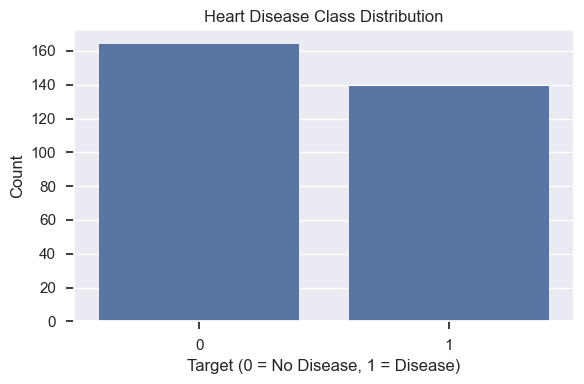

In [7]:
"""
Check class balance to identify potential imbalance issues.
"""

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Heart Disease Class Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


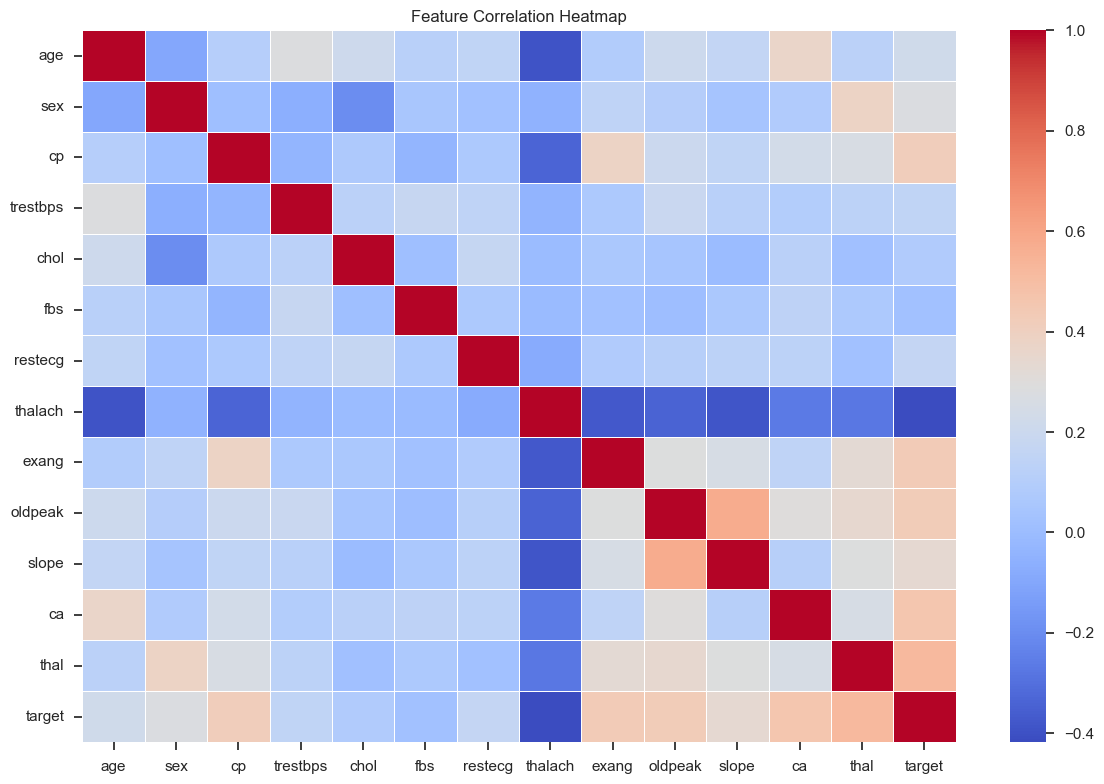

In [8]:
"""
Correlation analysis helps identify:
- Highly correlated features
- Potential multicollinearity
"""

plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


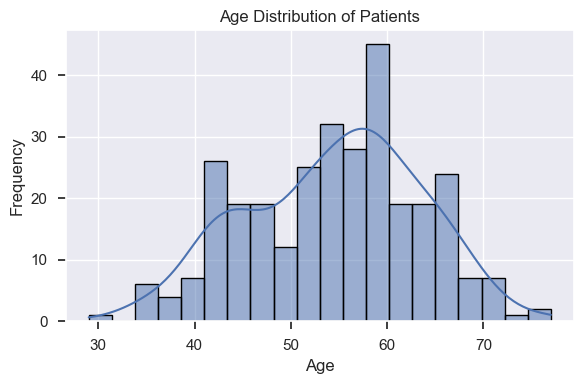

In [9]:
"""
Understand the age distribution of patients in the dataset.
"""

plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [10]:
"""
Persist the cleaned dataset.

This file will be used for:
- Feature engineering
- Model training
- CI/CD pipelines
- Docker builds
"""

df.to_csv("../data/heart_cleaned.csv", index=False)


In [11]:
"""
Final dataset validation before moving to modeling.
"""

print("Dataset Shape:", df.shape)
print("Target Distribution:")
print(df["target"].value_counts(normalize=True))


Dataset Shape: (303, 14)
Target Distribution:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [12]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64